# Calculate VIX Index from SPX Option Chain

In this assignment, you will write a function program to calculate the **VIX index** from the enclosed data packet. The CBOE white paper on VIX calculation is included for your reference.

The SPX option chain data files contain the following information at the time of quote capture:
1. **SPX index level** 
2. **Date and Time stamp** 
3. **Quotes for all the strikes** for each maturity of the option chain 

The `TBillQuotes_20231128.csv` file contains the Treasury bill market quotes. You should:
1. Build a **risk-free interest rate curve** based on the mid-price of each T-bill quote.
2. Use **interpolation** to find the relevant rate to calculate the forward price needed, using a **dividend yield of 1.56%** for the SPX index.

Run your program and print out the VIX index you've obtained.

**Good luck!** 

In [196]:
import pandas as pd
import datetime
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt
from scipy import interpolate
import numpy as np

## Load the data

In [198]:
column_names_Tbills_quote = ["Identifier", "Security_Type", "Coupon", "Maturity_Date", "Placeholder", "Bid_Price", "Ask_Price", "Yield_Change"]
Tbills_quote_df = pd.read_csv("hw#8_VIXCalucation/TBillQuotes_20231128.csv", header=None, names=column_names_Tbills_quote)
Tbills_quote_df.head()

,Identifier,Security_Type,Coupon,Maturity_Date,Placeholder,Bid_Price,Ask_Price,Yield_Change
0,912796ZD4,MARKET BASED BILL,0.0,11/30/2023,NaN,0.000000,99.970833,0.0
1,912797HN0,MARKET BASED BILL,0.0,12/05/2023,NaN,99.897722,99.897528,0.0
2,912797FT9,MARKET BASED BILL,0.0,12/07/2023,NaN,99.868625,99.868250,0.0
3,912797HU4,MARKET BASED BILL,0.0,12/12/2023,NaN,99.795250,99.795056,0.0
4,912797FU6,MARKET BASED BILL,0.0,12/14/2023,NaN,99.766667,99.766222,0.0


In [199]:
Tbills_quote_df.dtypes

Identifier        object
Security_Type     object
Coupon           float64
Maturity_Date     object
Placeholder      float64
Bid_Price        float64
Ask_Price        float64
Yield_Change     float64
dtype: object

Looks like we got to convert the `Maturity_Date` column to a datetime type

In [201]:
Tbills_quote_df['Maturity_Date'] = pd.to_datetime(Tbills_quote_df['Maturity_Date'], format='%m/%d/%Y')
Tbills_quote_df.head()

,Identifier,Security_Type,Coupon,Maturity_Date,Placeholder,Bid_Price,Ask_Price,Yield_Change
0,912796ZD4,MARKET BASED BILL,0.0,2023-11-30,NaN,0.000000,99.970833,0.0
1,912797HN0,MARKET BASED BILL,0.0,2023-12-05,NaN,99.897722,99.897528,0.0
2,912797FT9,MARKET BASED BILL,0.0,2023-12-07,NaN,99.868625,99.868250,0.0
3,912797HU4,MARKET BASED BILL,0.0,2023-12-12,NaN,99.795250,99.795056,0.0
4,912797FU6,MARKET BASED BILL,0.0,2023-12-14,NaN,99.766667,99.766222,0.0


In [202]:
Tbills_quote_df.dtypes

Identifier               object
Security_Type            object
Coupon                  float64
Maturity_Date    datetime64[ns]
Placeholder             float64
Bid_Price               float64
Ask_Price               float64
Yield_Change            float64
dtype: object

## 1. Process the Interest Rate Curve

In [204]:
# Because SPX data was captured at 3:34 PM (15:34) according to 'spx_202312_option_chain.csv'
valuation_date = pd.to_datetime('2023-11-28 15:34:00')
valuation_date

Timestamp('2023-11-28 15:34:00')

Now let us get the `Time_to_Maturity` in years.

In [206]:
# Now we gotta find the totl seconds and divide by total seconds of a 365-day year
seconds_in_year = 365 * 24 *3600
Tbills_quote_df['Time_to_Maturity'] = (Tbills_quote_df['Maturity_Date'] - valuation_date).dt.total_seconds() / seconds_in_year

Tbills_quote_df.head()

,Identifier,Security_Type,Coupon,Maturity_Date,Placeholder,Bid_Price,Ask_Price,Yield_Change,Time_to_Maturity
0,912796ZD4,MARKET BASED BILL,0.0,2023-11-30,NaN,0.000000,99.970833,0.0,0.003702
1,912797HN0,MARKET BASED BILL,0.0,2023-12-05,NaN,99.897722,99.897528,0.0,0.017401
2,912797FT9,MARKET BASED BILL,0.0,2023-12-07,NaN,99.868625,99.868250,0.0,0.022881
3,912797HU4,MARKET BASED BILL,0.0,2023-12-12,NaN,99.795250,99.795056,0.0,0.036579
4,912797FU6,MARKET BASED BILL,0.0,2023-12-14,NaN,99.766667,99.766222,0.0,0.042059


We also need to build a risk free interest rate curve based on the mid-price of each T-bill quote. So now let us get the `Mid_Price` which is by calculating:
$$P_{mid} = \frac{P_{bid} + P_{ask}}{2}$$

In [208]:
# THE CRITICAL FIX: Filter out rows with Bid_Price == 0 BEFORE any math
# We also ensure Time_to_Maturity > 0 to avoid division by zero
Tbills_quote_df = Tbills_quote_df[(Tbills_quote_df['Bid_Price'] > 0) & (Tbills_quote_df['Time_to_Maturity'] > 0)].copy()

Tbills_quote_df['Mid_Price'] = (Tbills_quote_df['Bid_Price'] + Tbills_quote_df['Ask_Price']) / 2
Tbills_quote_df.head()

,Identifier,Security_Type,Coupon,Maturity_Date,Placeholder,Bid_Price,Ask_Price,Yield_Change,Time_to_Maturity,Mid_Price
1,912797HN0,MARKET BASED BILL,0.0,2023-12-05,NaN,99.897722,99.897528,0.0,0.017401,99.897625
2,912797FT9,MARKET BASED BILL,0.0,2023-12-07,NaN,99.868625,99.868250,0.0,0.022881,99.868437
3,912797HU4,MARKET BASED BILL,0.0,2023-12-12,NaN,99.795250,99.795056,0.0,0.036579,99.795153
4,912797FU6,MARKET BASED BILL,0.0,2023-12-14,NaN,99.766667,99.766222,0.0,0.042059,99.766445
5,912797HV2,MARKET BASED BILL,0.0,2023-12-19,NaN,99.692583,99.692000,0.0,0.055757,99.692291


Now let us find the Annualized Interest Rate ($R$)

$$R = \left( \frac{100 - \text{Mid Price}}{\text{Mid Price}} \right) \times \frac{1}{T}$$

* **100**: The face value of the T-bill.
* $T$: The fraction of the 365-day year we calculated in the previous step.
* **Result**: This will give us a decimal (e.g., 0.053 for 5.3%).

In [210]:
# Add this 
Tbills_quote_df['Annualized_IR'] = (100 - Tbills_quote_df['Mid_Price']) / (Tbills_quote_df['Mid_Price'] * Tbills_quote_df['Time_to_Maturity'])
Tbills_quote_df.head()

,Identifier,Security_Type,Coupon,Maturity_Date,Placeholder,Bid_Price,Ask_Price,Yield_Change,Time_to_Maturity,Mid_Price,Annualized_IR
1,912797HN0,MARKET BASED BILL,0.0,2023-12-05,NaN,99.897722,99.897528,0.0,0.017401,99.897625,0.058893
2,912797FT9,MARKET BASED BILL,0.0,2023-12-07,NaN,99.868625,99.868250,0.0,0.022881,99.868437,0.057576
3,912797HU4,MARKET BASED BILL,0.0,2023-12-12,NaN,99.795250,99.795056,0.0,0.036579,99.795153,0.056116
4,912797FU6,MARKET BASED BILL,0.0,2023-12-14,NaN,99.766667,99.766222,0.0,0.042059,99.766445,0.055661
5,912797HV2,MARKET BASED BILL,0.0,2023-12-19,NaN,99.692583,99.692000,0.0,0.055757,99.692291,0.055358


In [211]:
Tbills_quote_df['Annualized_IR'].isna().sum()   

0

In [212]:
Tbills_quote_df['Time_to_Maturity'].isna().sum()   

0

In [213]:
Tbills_quote_df = Tbills_quote_df.sort_values(by='Time_to_Maturity')
Tbills_quote_df.head()

,Identifier,Security_Type,Coupon,Maturity_Date,Placeholder,Bid_Price,Ask_Price,Yield_Change,Time_to_Maturity,Mid_Price,Annualized_IR
1,912797HN0,MARKET BASED BILL,0.0,2023-12-05,NaN,99.897722,99.897528,0.0,0.017401,99.897625,0.058893
2,912797FT9,MARKET BASED BILL,0.0,2023-12-07,NaN,99.868625,99.868250,0.0,0.022881,99.868437,0.057576
3,912797HU4,MARKET BASED BILL,0.0,2023-12-12,NaN,99.795250,99.795056,0.0,0.036579,99.795153,0.056116
4,912797FU6,MARKET BASED BILL,0.0,2023-12-14,NaN,99.766667,99.766222,0.0,0.042059,99.766445,0.055661
5,912797HV2,MARKET BASED BILL,0.0,2023-12-19,NaN,99.692583,99.692000,0.0,0.055757,99.692291,0.055358


In [214]:
rf_curve = interpolate.interp1d(
    Tbills_quote_df['Time_to_Maturity'],
    Tbills_quote_df['Annualized_IR'],
    kind='linear',
    fill_value='extrapolate'
)
rf_curve

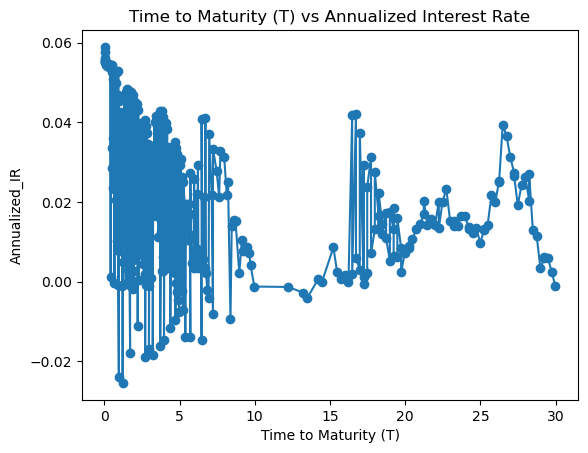

In [215]:
plt.plot(Tbills_quote_df['Time_to_Maturity'], Tbills_quote_df['Annualized_IR'], marker='o')
plt.title('Time to Maturity (T) vs Annualized Interest Rate')
plt.xlabel('Time to Maturity (T)')
plt.ylabel('Annualized_IR')
plt.show()

## 2: Option Selection and Forward Price

In [217]:
spx_202401_df = pd.read_csv("hw#8_VIXCalucation/spx_202401_option_chain.csv",skiprows=3)
spx_202312_df = pd.read_csv("hw#8_VIXCalucation/spx_202312_option_chain.csv",skiprows=3)
spx_202311_df = pd.read_csv("hw#8_VIXCalucation/spx_202311_option_chain.csv",skiprows=3)

In [218]:
spx_202401_df['Expiration Date'] = pd.to_datetime(spx_202401_df['Expiration Date'], format='%a %b %d %Y')
spx_202312_df['Expiration Date'] = pd.to_datetime(spx_202312_df['Expiration Date'], format='%a %b %d %Y')
spx_202311_df['Expiration Date'] = pd.to_datetime(spx_202311_df['Expiration Date'], format='%a %b %d %Y')

spx_202401_df.dtypes

Expiration Date    datetime64[ns]
Calls                      object
Last Sale                 float64
Net                       float64
Bid                       float64
Ask                       float64
Volume                      int64
IV                        float64
Delta                     float64
Gamma                     float64
Open Interest               int64
Strike                    float64
Puts                       object
Last Sale.1               float64
Net.1                     float64
Bid.1                     float64
Ask.1                     float64
Volume.1                    int64
IV.1                      float64
Delta.1                   float64
Gamma.1                   float64
Open Interest.1             int64
dtype: object

In [219]:
spx_202311_df.head()

,Expiration Date,Calls,Last Sale,Net,Bid,Ask,Volume,IV,Delta,Gamma,...,Puts,Last Sale.1,Net.1,Bid.1,Ask.1,Volume.1,IV.1,Delta.1,Gamma.1,Open Interest.1
0,2023-11-28,SPXW231128C01200000,3354.1,0.0,3350.1,3350.6,0,0.0,1.0,0.0,...,SPXW231128P01200000,0.03,0.0,0.0,0.05,0,0.0,0.0,0.0,2
1,2023-11-28,SPXW231128C01400000,0.0,0.0,3150.1,3150.6,0,0.0,1.0,0.0,...,SPXW231128P01400000,0.00,0.0,0.0,0.05,0,0.0,0.0,0.0,0
2,2023-11-28,SPXW231128C01600000,0.0,0.0,2950.1,2950.6,0,0.0,1.0,0.0,...,SPXW231128P01600000,0.00,0.0,0.0,0.05,0,0.0,0.0,0.0,0
3,2023-11-28,SPXW231128C01800000,0.0,0.0,2750.1,2750.6,0,0.0,1.0,0.0,...,SPXW231128P01800000,0.15,0.0,0.0,0.05,0,0.0,0.0,0.0,4
4,2023-11-28,SPXW231128C02000000,0.0,0.0,2550.1,2550.6,0,0.0,1.0,0.0,...,SPXW231128P02000000,0.05,0.0,0.0,0.05,0,0.0,0.0,0.0,8


Assuming the Expiration Time is [9:30am](!https://www.cmegroup.com/articles/faqs/sanp-500-month-end-futures-and-options.html) for SPX Monthly options. Let's append 9:30am to the expiration dates.

In [221]:
spx_202401_df['Expiration Date'] = spx_202401_df['Expiration Date'].dt.normalize() + pd.to_timedelta("09:30:00")
spx_202312_df['Expiration Date'] = spx_202312_df['Expiration Date'].dt.normalize() + pd.to_timedelta("09:30:00")
spx_202311_df['Expiration Date'] = spx_202311_df['Expiration Date'].dt.normalize() + pd.to_timedelta("09:30:00")

spx_202311_df.head()

,Expiration Date,Calls,Last Sale,Net,Bid,Ask,Volume,IV,Delta,Gamma,...,Puts,Last Sale.1,Net.1,Bid.1,Ask.1,Volume.1,IV.1,Delta.1,Gamma.1,Open Interest.1
0,2023-11-28 09:30:00,SPXW231128C01200000,3354.1,0.0,3350.1,3350.6,0,0.0,1.0,0.0,...,SPXW231128P01200000,0.03,0.0,0.0,0.05,0,0.0,0.0,0.0,2
1,2023-11-28 09:30:00,SPXW231128C01400000,0.0,0.0,3150.1,3150.6,0,0.0,1.0,0.0,...,SPXW231128P01400000,0.00,0.0,0.0,0.05,0,0.0,0.0,0.0,0
2,2023-11-28 09:30:00,SPXW231128C01600000,0.0,0.0,2950.1,2950.6,0,0.0,1.0,0.0,...,SPXW231128P01600000,0.00,0.0,0.0,0.05,0,0.0,0.0,0.0,0
3,2023-11-28 09:30:00,SPXW231128C01800000,0.0,0.0,2750.1,2750.6,0,0.0,1.0,0.0,...,SPXW231128P01800000,0.15,0.0,0.0,0.05,0,0.0,0.0,0.0,4
4,2023-11-28 09:30:00,SPXW231128C02000000,0.0,0.0,2550.1,2550.6,0,0.0,1.0,0.0,...,SPXW231128P02000000,0.05,0.0,0.0,0.05,0,0.0,0.0,0.0,8


In [222]:
# Now we gotta find the totl seconds and divide by total seconds of a 365-day year
spx_202401_df['Time_to_Maturity'] = (spx_202401_df['Expiration Date'] - valuation_date).dt.total_seconds() / seconds_in_year

# Let's also filter out any T-bills that have already matured (T <= 0). 
# That way we avoid division error by 0
spx_202401_df = spx_202401_df[spx_202401_df['Time_to_Maturity']>0]

# -------------------------------------------------------------------------------
# Now we gotta find the totl seconds and divide by total seconds of a 365-day year
spx_202312_df['Time_to_Maturity'] = (spx_202312_df['Expiration Date'] - valuation_date).dt.total_seconds() / seconds_in_year

# Let's also filter out any T-bills that have already matured (T <= 0). 
# That way we avoid division error by 0
spx_202312_df = spx_202312_df[spx_202312_df['Time_to_Maturity']>0]

# -------------------------------------------------------------------------------
# Now we gotta find the totl seconds and divide by total seconds of a 365-day year
spx_202311_df['Time_to_Maturity'] = (spx_202311_df['Expiration Date'] - valuation_date).dt.total_seconds() / seconds_in_year

# Let's also filter out any T-bills that have already matured (T <= 0). 
# That way we avoid division error by 0
spx_202311_df = spx_202311_df[spx_202311_df['Time_to_Maturity']>0]

spx_202311_df.head()

,Expiration Date,Calls,Last Sale,Net,Bid,Ask,Volume,IV,Delta,Gamma,...,Last Sale.1,Net.1,Bid.1,Ask.1,Volume.1,IV.1,Delta.1,Gamma.1,Open Interest.1,Time_to_Maturity
183,2023-11-29 09:30:00,SPXW231129C01200000,3325.26,0.0,3349.1,3350.4,0,0.0000,1.0,0.0,...,0.05,0.0,0.0,0.05,0,6.9062,0.0,0.0,0,0.002047
184,2023-11-29 09:30:00,SPXW231129C01400000,2762.21,0.0,3149.2,3150.4,0,6.0046,1.0,0.0,...,0.05,0.0,0.0,0.05,0,6.1234,0.0,0.0,6,0.002047
185,2023-11-29 09:30:00,SPXW231129C01600000,0.00,0.0,2949.3,2950.4,0,5.5803,1.0,0.0,...,0.00,0.0,0.0,0.05,0,5.4467,0.0,0.0,0,0.002047
186,2023-11-29 09:30:00,SPXW231129C01800000,0.00,0.0,2749.2,2750.4,0,0.0000,1.0,0.0,...,0.12,0.0,0.0,0.05,0,4.8499,0.0,0.0,5,0.002047
187,2023-11-29 09:30:00,SPXW231129C02000000,0.00,0.0,2549.3,2550.5,0,4.3083,1.0,0.0,...,0.20,0.0,0.0,0.05,0,4.3167,0.0,0.0,6,0.002047


The components of the VIX Index are near- and next-term put and call options with more than 23 days and less than 37 days to expiration but we shall use `> 0` to allow to be processed

In [224]:
# 1. Define a helper to get the rate only if the dataframe isn't empty
def get_clean_rate_and_time_to_maturity(df, name):
    # Grab the first T value
    t_value = df['Time_to_Maturity'].iloc[0]
        
    # Only interpolate if T is positive and meaningful 
    # Even though by right (VIX uses > 23 days and < 37 days) we shall use >0 to allow to be processed
    if t_value > 0 and t_value < (37/365):
        rate = rf_curve(t_value).item()
        print(f"{name} Rate (R): {rate:.6f} for T: {t_value:.6f}")
        return rate, t_value
    print(f"VIX uses > 23 days and < 37 days. Month of {name} invalid")
    return None

# 2. Apply to your datasets

# Ok I kind of excluded spx_202311_df because 2023-11-29 09:30:00 is very close 
# our valuation date of 2023-11-28 15:34:00 which would result in
# RuntimeWarning: divide by zero encountered in divide slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
result_nov = get_clean_rate_and_time_to_maturity(spx_202311_df, "November")
result_dec = get_clean_rate_and_time_to_maturity(spx_202312_df, "December")
result_jan = get_clean_rate_and_time_to_maturity(spx_202401_df, "January")

if result_nov:
    r_nov, t_nov = result_nov
    print(f"""
    Interpolate interest rate for Nov: {r_nov} 
    Time to maturity for Nov: {t_nov}
    """)
else:
    r_nov, t_nov = None, None
    print(f"""
    Interpolate interest rate for Nov: {r_nov} 
    Time to maturity for Nov: {t_nov}
    """)

if result_dec:
    r_dec, t_dec = result_dec
    print(f"""
    Interpolate interest rate for Dec: {r_dec} 
    Time to maturity for Dec: {t_dec}
    """)
else:
    r_dec, t_dec = None, None
    print(f"""
    Interpolate interest rate for Dec: {r_dec} 
    Time to maturity for Dec: {t_dec}
    """)

if result_jan:
    r_jan, t_jan = result_jan
    print(f"""
    Interpolate interest rate for Jan: {r_jan} 
    Time to maturity for Jan: {t_jan}
    """)
else:
    r_jan, t_jan = None, None
    print(f"""
    Interpolate interest rate for Jan: {r_jan} 
    Time to maturity for Jan: {t_jan}
    """)

November Rate (R): 0.062584 for T: 0.002047
December Rate (R): 0.061267 for T: 0.007527
January Rate (R): 0.054766 for T: 0.095198

    Interpolate interest rate for Nov: 0.06258423754298136 
    Time to maturity for Nov: 0.0020471841704718416
    

    Interpolate interest rate for Dec: 0.061266881460262185 
    Time to maturity for Dec: 0.007526636225266363
    

    Interpolate interest rate for Jan: 0.054765506810912114 
    Time to maturity for Jan: 0.0951978691019787
    


In [225]:
# 3. Assign to columns ONLY if a rate was found
if r_jan:
    spx_202401_df['Interpolated_Interest_Rate'] = r_jan
if r_dec:
    spx_202312_df['Interpolated_Interest_Rate'] = r_dec
if r_nov:
    spx_202311_df['Interpolated_Interest_Rate'] = r_nov

In [226]:
spx_202401_df.head()

,Expiration Date,Calls,Last Sale,Net,Bid,Ask,Volume,IV,Delta,Gamma,...,Net.1,Bid.1,Ask.1,Volume.1,IV.1,Delta.1,Gamma.1,Open Interest.1,Time_to_Maturity,Interpolated_Interest_Rate
0,2024-01-02 09:30:00,SPXW240102C01200000,3343.2,-15.1,3347.5,3355.9,1,1.2073,1.0,0.0,...,0.0,0.0,0.05,0,1.1876,-0.0001,0.0,0,0.095198,0.054766
1,2024-01-02 09:30:00,SPXW240102C01400000,0.0,0.0,3148.6,3156.9,0,1.0808,1.0,0.0,...,0.0,0.0,0.05,0,1.0534,-0.0001,0.0,0,0.095198,0.054766
2,2024-01-02 09:30:00,SPXW240102C01600000,0.0,0.0,2949.7,2957.9,0,0.9697,1.0,0.0,...,0.0,0.0,0.10,0,0.9799,-0.0002,0.0,0,0.095198,0.054766
3,2024-01-02 09:30:00,SPXW240102C01800000,0.0,0.0,2750.8,2759.0,0,0.9150,1.0,0.0,...,0.0,0.0,0.10,0,0.8733,-0.0002,0.0,0,0.095198,0.054766
4,2024-01-02 09:30:00,SPXW240102C02000000,0.0,0.0,2551.9,2560.0,0,0.8184,1.0,0.0,...,0.0,0.0,0.10,0,0.7779,-0.0002,0.0,0,0.095198,0.054766


Now let us calculate the Forward Price ($F$) of `spx_202401_df` and `spx_202312_df`

$$F = S \times e^{(R - d)T}$$

In [228]:
dividend_yield = 0.0156
S_spot = 4549.9102

In [229]:
# Calculate for January using January's R and T
F_jan = S_spot * np.exp((r_jan - dividend_yield) * spx_202401_df['Time_to_Maturity'].iloc[0])
spx_202401_df['Forward_Price'] = F_jan

print(f"Forward Price Jan: {F_jan}")

Forward Price Jan: 4566.906081031781


In [230]:
# Calculate for December using December's R and T
F_dec = S_spot * np.exp((r_dec - dividend_yield) * spx_202312_df['Time_to_Maturity'].iloc[0])
spx_202312_df['Forward_Price'] = F_dec

print(f"Forward Price Dec: {F_dec}")

Forward Price Dec: 4551.474354852353


In [231]:
# Calculate for November using December's R and T
F_nov = S_spot * np.exp((r_nov - dividend_yield) * spx_202311_df['Time_to_Maturity'].iloc[0])
spx_202311_df['Forward_Price'] = F_nov

print(f"Forward Price Dec: {F_dec}")

Forward Price Dec: 4551.474354852353


Now let us find the respective **Pivot Strike price** for December and January datasets.


* We find the **Pivot Strike ($K_0$)** by finding the highest available strike price in each dataset that is less than or equal to your calculated Forward Price (F).
* We find the mathematical center of the option chain.
* The **Pivot Strike** is used later to separate Out-of-the-Money Puts from Out-of-the-Money Calls for the final VIX variance calculation.

In [233]:
# Identify K0 for January (using F_jan)
K0_jan = spx_202401_df[spx_202401_df["Strike"] <= F_jan]["Strike"].max()
K0_dec = spx_202312_df[spx_202312_df["Strike"] <= F_dec]["Strike"].max()
K0_nov = spx_202311_df[spx_202311_df["Strike"] <= F_nov]["Strike"].max()

print(f"K0 Jan: {K0_jan}")
print(f"K0 Dec: {K0_dec}")
print(f"K0 Noc: {K0_nov}")

K0 Jan: 4565.0
K0 Dec: 4550.0
K0 Noc: 4550.0


Now we shall find the **Mid-Price**

In [235]:
spx_202401_df["Call_Mid_Price"] = (spx_202401_df["Bid"] + spx_202401_df["Ask"])/2
spx_202401_df["Put_Mid_Price"] = (spx_202401_df["Bid.1"] + spx_202401_df["Ask.1"])/2
spx_202312_df["Call_Mid_Price"] = (spx_202312_df["Bid"] + spx_202312_df["Ask"])/2
spx_202312_df["Put_Mid_Price"] = (spx_202312_df["Bid.1"] + spx_202312_df["Ask.1"])/2
spx_202311_df["Call_Mid_Price"] = (spx_202311_df["Bid"] + spx_202311_df["Ask"])/2
spx_202311_df["Put_Mid_Price"] = (spx_202311_df["Bid.1"] + spx_202311_df["Ask.1"])/2

spx_202401_df.head()

,Expiration Date,Calls,Last Sale,Net,Bid,Ask,Volume,IV,Delta,Gamma,...,Volume.1,IV.1,Delta.1,Gamma.1,Open Interest.1,Time_to_Maturity,Interpolated_Interest_Rate,Forward_Price,Call_Mid_Price,Put_Mid_Price
0,2024-01-02 09:30:00,SPXW240102C01200000,3343.2,-15.1,3347.5,3355.9,1,1.2073,1.0,0.0,...,0,1.1876,-0.0001,0.0,0,0.095198,0.054766,4566.906081,3351.70,0.025
1,2024-01-02 09:30:00,SPXW240102C01400000,0.0,0.0,3148.6,3156.9,0,1.0808,1.0,0.0,...,0,1.0534,-0.0001,0.0,0,0.095198,0.054766,4566.906081,3152.75,0.025
2,2024-01-02 09:30:00,SPXW240102C01600000,0.0,0.0,2949.7,2957.9,0,0.9697,1.0,0.0,...,0,0.9799,-0.0002,0.0,0,0.095198,0.054766,4566.906081,2953.80,0.050
3,2024-01-02 09:30:00,SPXW240102C01800000,0.0,0.0,2750.8,2759.0,0,0.9150,1.0,0.0,...,0,0.8733,-0.0002,0.0,0,0.095198,0.054766,4566.906081,2754.90,0.050
4,2024-01-02 09:30:00,SPXW240102C02000000,0.0,0.0,2551.9,2560.0,0,0.8184,1.0,0.0,...,0,0.7779,-0.0002,0.0,0,0.095198,0.054766,4566.906081,2555.95,0.050


In [236]:
spx_202401_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1524 entries, 0 to 1523
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Expiration Date             1524 non-null   datetime64[ns]
 1   Calls                       1524 non-null   object        
 2   Last Sale                   1524 non-null   float64       
 3   Net                         1524 non-null   float64       
 4   Bid                         1524 non-null   float64       
 5   Ask                         1524 non-null   float64       
 6   Volume                      1524 non-null   int64         
 7   IV                          1524 non-null   float64       
 8   Delta                       1524 non-null   float64       
 9   Gamma                       1524 non-null   float64       
 10  Open Interest               1524 non-null   int64         
 11  Strike                      1524 non-null   float64     

### a) We shall first filter and choose the VIX Price ($Q(K)$)

For the VIX formula it needs a single price of $Q(K_i)$, for every strike.

To obtain this we need the midpoint of the bid-ask spread to represent the fair market value.

* If $K < K_0$: Use Puts. (A put is OTM if the strike < current price).
* If $K > K_0$: Use Calls. (A call is OTM if the strike > current price).
* If $K = K_0$: Use the average of the Put and Call mid-prices to find the ATM center.

Afterwards as option with a **Bid of 0** can't be defined in volatility perspective. What we do is identify the relevants bids and filtering for only values where `df[df['Relevant_Bid'] > 0]`

Finally to prepare for the next step we gotta sort the values of $K$ which is essential for computing $\Delta K$.

In [238]:
def get_vix_contribution_price(df,K0):
    df = df.copy()

    def price_chooser(row):
        if row["Strike"] < K0:
            return row['Put_Mid_Price'], row['Bid.1']
        elif row['Strike'] > K0:
            return row['Call_Mid_Price'], row['Bid']

        else:
            return (row['Call_Mid_Price'] + row['Put_Mid_Price']) / 2, min(row['Bid'], row['Bid.1'])

    df[['Q_K', 'Relevant_Bid']] = df.apply(lambda r: pd.Series(price_chooser(r)), axis=1)
    
    # This is crucial in filtering out the zero-bids
    df = df[df['Relevant_Bid'] > 0] 

    return df.sort_values('Strike')

In [239]:
df_jan_filtered = get_vix_contribution_price(spx_202401_df, K0_jan)

df_dec_filtered = get_vix_contribution_price(spx_202312_df, K0_dec)

df_nov_filtered = get_vix_contribution_price(spx_202311_df, K0_nov)

df_jan_filtered.head()

,Expiration Date,Calls,Last Sale,Net,Bid,Ask,Volume,IV,Delta,Gamma,...,Delta.1,Gamma.1,Open Interest.1,Time_to_Maturity,Interpolated_Interest_Rate,Forward_Price,Call_Mid_Price,Put_Mid_Price,Q_K,Relevant_Bid
1195,2024-01-31 09:30:00,SPXW240131C01700000,0.00,0.0,2854.7,2862.1,0,0.0,1.0,0.0,...,-0.0004,0.0,1387,0.174650,0.054766,4566.906081,2858.40,0.100,0.100,0.05
1196,2024-01-31 09:30:00,SPXW240131C01800000,0.00,0.0,2755.6,2763.1,0,0.0,1.0,0.0,...,-0.0004,0.0,1417,0.174650,0.054766,4566.906081,2759.35,0.125,0.125,0.10
476,2024-01-19 09:30:00,SPXW240119C01800000,2716.01,0.0,2753.9,2761.5,0,0.0,1.0,0.0,...,-0.0003,0.0,169,0.141773,0.054766,4566.906081,2757.70,0.075,0.075,0.05
478,2024-01-19 09:30:00,SPXW240119C01900000,0.00,0.0,2654.8,2662.4,0,0.0,1.0,0.0,...,-0.0004,0.0,191,0.141773,0.054766,4566.906081,2658.60,0.075,0.075,0.05
477,2024-01-19 09:30:00,SPX240119C01900000,0.00,0.0,2652.5,2664.9,0,0.0,1.0,0.0,...,-0.0004,0.0,9011,0.141773,0.054766,4566.906081,2658.70,0.075,0.075,0.05


### b) Calculate $\Delta K$ (Strike Intervals)

This is essential as we want to find the horizontal width $(\Delta K)$ related to each strike price. Strike prices are not always like perfectly spaced so we got to have $\Delta K$ to take the weight of each price properly.

$$\Delta K_i = \frac{K_{i+1} - K_{i-1}}{2}$$

An exception to this formula would probably be the very first strike and last strike in the dataframe. This is because for the first strike there isn't a strike that comes before it so we gotta take the distance to the strike that comes right after. Whereas for the last strike there isn't a strike that comes after so we gotta take the strike that comes like right before it.

In [241]:
def find_delta_k(df):
    strikes = df["Strike"].values
    delta_k = np.zeros(len(strikes))

    # Gotta find the mid-strikes and apply formula of:
    # $$\Delta K_i = \frac{K_{i+1} - K_{i-1}}{2}$$
    delta_k[1:-1] = (strikes[2:] - strikes[:-2])/2

    # Boundary strikes which are basically the first and last strikes
    delta_k[0] = strikes[1] - strikes[0]
    delta_k[-1] = strikes[-1] - strikes[-2]

    df['Delta_K'] = delta_k
    
    return df

In [242]:
df_jan_filtered_post_k = find_delta_k(df_jan_filtered)
df_dec_filtered_post_k = find_delta_k(df_dec_filtered)
df_nov_filtered_post_k = find_delta_k(df_nov_filtered)

df_jan_filtered_post_k.head()

,Expiration Date,Calls,Last Sale,Net,Bid,Ask,Volume,IV,Delta,Gamma,...,Gamma.1,Open Interest.1,Time_to_Maturity,Interpolated_Interest_Rate,Forward_Price,Call_Mid_Price,Put_Mid_Price,Q_K,Relevant_Bid,Delta_K
1195,2024-01-31 09:30:00,SPXW240131C01700000,0.00,0.0,2854.7,2862.1,0,0.0,1.0,0.0,...,0.0,1387,0.174650,0.054766,4566.906081,2858.40,0.100,0.100,0.05,100.0
1196,2024-01-31 09:30:00,SPXW240131C01800000,0.00,0.0,2755.6,2763.1,0,0.0,1.0,0.0,...,0.0,1417,0.174650,0.054766,4566.906081,2759.35,0.125,0.125,0.10,50.0
476,2024-01-19 09:30:00,SPXW240119C01800000,2716.01,0.0,2753.9,2761.5,0,0.0,1.0,0.0,...,0.0,169,0.141773,0.054766,4566.906081,2757.70,0.075,0.075,0.05,50.0
478,2024-01-19 09:30:00,SPXW240119C01900000,0.00,0.0,2654.8,2662.4,0,0.0,1.0,0.0,...,0.0,191,0.141773,0.054766,4566.906081,2658.60,0.075,0.075,0.05,50.0
477,2024-01-19 09:30:00,SPX240119C01900000,0.00,0.0,2652.5,2664.9,0,0.0,1.0,0.0,...,0.0,9011,0.141773,0.054766,4566.906081,2658.70,0.075,0.075,0.05,0.0


### c) Calculate Variance ($\sigma^2$) for each Term

We basically apply the formmula below.
$$\sigma^2 = \frac{2}{T} \sum_i \frac{\Delta K_i}{K_i^2} e^{RT} Q(K_i) - \frac{1}{T} \left[ \frac{F}{K_0} - 1 \right]^2$$

In [244]:
def variance_computer(df, T, R, F, K0):
    # We first find this:
    # \frac{2}{T} \sum_i \frac{\Delta K_i}{K_i^2} e^{RT} Q(K_i)
    df['Contribution'] = (df['Delta_K']/ (df['Strike']**2)) * np.exp(R*T) * df['Q_K']
    summation_of_first_term = df['Contribution'].sum()

    # Then we take into account the other component
    variance = (2/T) * summation_of_first_term - (1/T)*((F/K0) -1)**2
    return variance

In [245]:
variance_jan = variance_computer(df_jan_filtered_post_k, t_jan, r_jan, F_jan,K0_jan)
print(f"Variance for Jan: {variance_jan:.6f}")
variance_dec = variance_computer(df_dec_filtered_post_k, t_dec, r_dec, F_dec,K0_dec)
print(f"Variance for Dec: {variance_dec:.6f}")
variance_nov = variance_computer(df_nov_filtered_post_k, t_nov, r_nov, F_nov,K0_nov)
print(f"Variance for Nov: {variance_dec:.6f}")

Variance for Jan: 0.028619
Variance for Dec: 0.096310
Variance for Nov: 0.096310


### d) Final VIX Interpolation
  
The VIX is a 30-day (constant maturity) index. We interpolate between our two terms to find exactly where "30 days" would land.

We apply the formulas of:

**Time-Weighted Variance**

$$\sigma^2_{30} = \left[ T_1 \sigma^2_1 \left( \frac{T_2 - T_{30}}{T_2 - T_1} \right) + T_2 \sigma^2_2 \left( \frac{T_{30} - T_1}{T_2 - T_1} \right) \right] \times \frac{1}{T_{30}}$$

**The Final VIX Number**

$$\text{VIX} = 100 \times \sqrt{\sigma^2_{30}}$$

In [247]:
spx_202312_df.head()

,Expiration Date,Calls,Last Sale,Net,Bid,Ask,Volume,IV,Delta,Gamma,...,Volume.1,IV.1,Delta.1,Gamma.1,Open Interest.1,Time_to_Maturity,Interpolated_Interest_Rate,Forward_Price,Call_Mid_Price,Put_Mid_Price
0,2023-12-01 09:30:00,SPXW231201C01200000,3296.85,0.0,3346.4,3352.4,0,0.0,1.0,0.0,...,0,4.0264,0.0,0.0,26,0.007527,0.061267,4551.474355,3349.40,0.025
1,2023-12-01 09:30:00,SPXW231201C01400000,0.00,0.0,3146.5,3152.6,0,0.0,1.0,0.0,...,0,3.5703,0.0,0.0,0,0.007527,0.061267,4551.474355,3149.55,0.025
2,2023-12-01 09:30:00,SPXW231201C01600000,0.00,0.0,2946.7,2952.7,0,0.0,1.0,0.0,...,0,3.1753,0.0,0.0,0,0.007527,0.061267,4551.474355,2949.70,0.025
3,2023-12-01 09:30:00,SPXW231201C01800000,0.00,0.0,2746.8,2752.9,0,0.0,1.0,0.0,...,0,2.8278,0.0,0.0,322,0.007527,0.061267,4551.474355,2749.85,0.025
4,2023-12-01 09:30:00,SPXW231201C02000000,2533.43,0.0,2547.0,2553.0,0,0.0,1.0,0.0,...,0,2.5170,0.0,0.0,423,0.007527,0.061267,4551.474355,2550.00,0.025


In [248]:
print(f"Dec Time to Maturity (days): {t_dec * 365}")
print(f"Dec Rate: {r_dec}")

Dec Time to Maturity (days): 2.7472222222222222
Dec Rate: 0.061266881460262185


In [249]:
print(f"Noc Time to Maturity (days): {t_nov * 365}")
print(f"Nov Rate: {r_nov}")

Noc Time to Maturity (days): 0.7472222222222221
Nov Rate: 0.06258423754298136


In [250]:
# Convert 30 days into the same 'year fraction' format (T)
# Minutes in 30 days / Minutes in 365-day year
T30 = (30 * 24 * 60) / (365 * 24 * 60) 

# Weighting formula
# VIX = 100 * sqrt( [T1*sigma1^2 * ((T2-T30)/(T2-T1)) + T2*sigma2^2 * ((T30-T1)/(T2-T1))] * (1/T30) )
term1 = t_dec * variance_dec * ((t_jan - T30) / (t_jan - t_dec))
term2 = t_jan * variance_jan * ((T30 - t_dec) / (t_jan - t_dec))

vix_index = 100 * np.sqrt((term1 + term2) / T30)

print(f"Final VIX Index Dec-Jan: {vix_index:.2f}")

Final VIX Index Dec-Jan: 17.19


In [251]:
# Convert 30 days into the same 'year fraction' format (T)
# Minutes in 30 days / Minutes in 365-day year
T30 = (30 * 24 * 60) / (365 * 24 * 60) 

# Weighting formula
# VIX = 100 * sqrt( [T1*sigma1^2 * ((T2-T30)/(T2-T1)) + T2*sigma2^2 * ((T30-T1)/(T2-T1))] * (1/T30) )
term1 = t_nov * variance_nov * ((t_dec - T30) / (t_dec - t_nov))
term2 = t_dec * variance_dec * ((T30 - t_nov) / (t_dec - t_nov))

vix_index = 100 * np.sqrt((term1 + term2) / T30)

print(f"Final VIX Index Nov-Dec: {vix_index:.2f}")

Final VIX Index Nov-Dec: 34.74
